# Notebook 03 — Train & Evaluate
## STOP 7 — Model Architecture

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
PROC = ROOT / "data" / "processed"
MODELS = ROOT / "models"
CHARTS = ROOT / "charts"
MODELS.mkdir(parents=True, exist_ok=True)
CHARTS.mkdir(parents=True, exist_ok=True)

arr = np.load(PROC / "dataset_arrays.npz")
X_train, X_val, X_test = arr["X_train"], arr["X_val"], arr["X_test"]
y_train, y_val, y_test = arr["y_train"], arr["y_val"], arr["y_test"]

train_loader = DataLoader(TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long)), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.long)), batch_size=64, shuffle=False)
test_loader = DataLoader(TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.long)), batch_size=64, shuffle=False)

class WineANN(nn.Module):
    def __init__(self, input_dim=11):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(128, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 3)
        )
    def forward(self, x):
        return self.net(x)

model = WineANN(input_dim=X_train.shape[1])
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=5, factor=0.5)

## STOP 8 — CrossEntropyLoss Deep Dive

In [2]:
xb, yb = next(iter(train_loader))
logits = model(xb)
loss = criterion(logits, yb)
print("logits shape:", logits.shape)
print("loss:", float(loss.item()))
print("sample probabilities:\n", torch.softmax(logits[:3], dim=1))

logits shape: torch.Size([64, 3])
loss: 1.402771234512329
sample probabilities:
 tensor([[0.6901, 0.1922, 0.1177],
        [0.7691, 0.0706, 0.1603],
        [0.2562, 0.4261, 0.3177]], grad_fn=<SoftmaxBackward0>)


## STOP 9 + 10 + 11 — Scheduler, Early Stopping, Training Loop

Early stopping at epoch 27


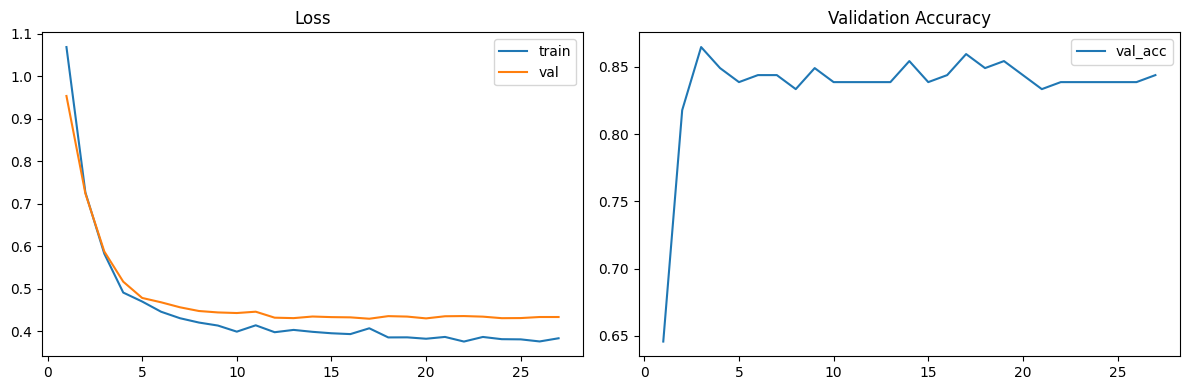

In [3]:
class EarlyStopping:
    def __init__(self, patience=10):
        self.patience = patience
        self.best = float("inf")
        self.counter = 0
        self.best_state = None

    def step(self, val_loss, model):
        if val_loss < self.best:
            self.best = val_loss
            self.counter = 0
            self.best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            return False
        self.counter += 1
        return self.counter >= self.patience

es = EarlyStopping(patience=10)
history = {"train_loss": [], "val_loss": [], "val_acc": []}

for epoch in range(1, 201):
    model.train()
    train_loss = 0.0
    train_n = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * yb.size(0)
        train_n += yb.size(0)

    model.eval()
    val_loss = 0.0
    preds, ys = [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            logits = model(xb)
            loss = criterion(logits, yb)
            val_loss += loss.item() * yb.size(0)
            preds.extend(torch.argmax(logits, dim=1).cpu().tolist())
            ys.extend(yb.cpu().tolist())

    tr_l = train_loss / train_n
    va_l = val_loss / len(ys)
    va_a = accuracy_score(ys, preds)
    history["train_loss"].append(tr_l)
    history["val_loss"].append(va_l)
    history["val_acc"].append(va_a)

    scheduler.step(va_l)
    if es.step(va_l, model):
        print(f"Early stopping at epoch {epoch}")
        break

if es.best_state is not None:
    model.load_state_dict(es.best_state)

x = np.arange(1, len(history["train_loss"]) + 1)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(x, history["train_loss"], label="train")
ax[0].plot(x, history["val_loss"], label="val")
ax[0].set_title("Loss")
ax[0].legend()
ax[1].plot(x, history["val_acc"], label="val_acc")
ax[1].set_title("Validation Accuracy")
ax[1].legend()
plt.tight_layout()
plt.savefig(CHARTS / "training_curves.png", dpi=180)
plt.show()

## STOP 12 — Multi-class Metrics

accuracy: 0.8375
macro_f1: 0.48389269606981783 weighted_f1: 0.8194350180108942


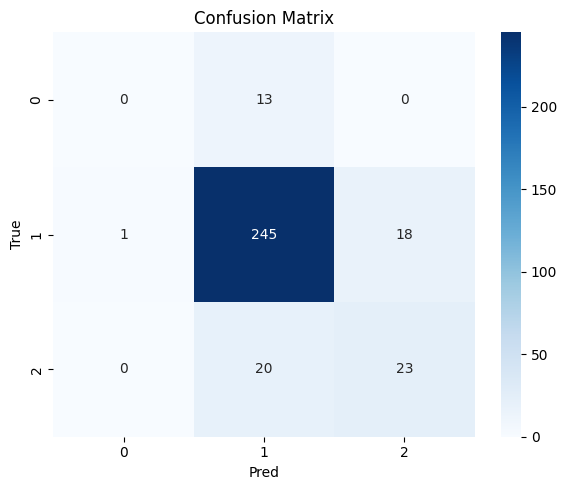

In [4]:
model.eval()
all_preds, all_y = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        logits = model(xb)
        all_preds.extend(torch.argmax(logits, dim=1).cpu().tolist())
        all_y.extend(yb.cpu().tolist())

acc = accuracy_score(all_y, all_preds)
report = classification_report(all_y, all_preds, output_dict=True, zero_division=0)
macro_f1 = f1_score(all_y, all_preds, average="macro")
weighted_f1 = f1_score(all_y, all_preds, average="weighted")

print("accuracy:", acc)
print("macro_f1:", macro_f1, "weighted_f1:", weighted_f1)

cm = confusion_matrix(all_y, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Pred")
plt.ylabel("True")
plt.tight_layout()
plt.savefig(CHARTS / "confusion_matrix.png", dpi=180)
plt.show()

## STOP 13 — Save & Load Pattern

In [5]:
torch.save(model.state_dict(), MODELS / "model.pkl")

results = {
    "accuracy": float(acc),
    "macro_f1": float(macro_f1),
    "weighted_f1": float(weighted_f1),
    "classification_report": report,
}
(MODELS / "results.json").write_text(json.dumps(results, indent=2))
(PROC / "training_history.json").write_text(json.dumps(history, indent=2))

# Verify load pattern
loaded = WineANN(input_dim=X_train.shape[1])
loaded.load_state_dict(torch.load(MODELS / "model.pkl", map_location="cpu"))
loaded.eval()
print("model saved and load verified")

model saved and load verified
